# Project Evolve - Phase 3: XAI Layer (Explainable AI)
## SHAP + LIME Explanations for Faculty Evaluation Scores

**Phase 3 Objective:**  
Provide transparent, interpretable explanations for every AI-generated faculty score using SHAP and LIME.

**Research Alignment:**  
- Ensures every insight is traceable  
- Highlights positive/negative contributing factors  
- Supports fairness audits (H2: XAI increases trust)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime.lime_tabular import LimeTabularExplainer
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print(" XAI libraries imported!")

 XAI libraries imported!


# Connect to Database

In [2]:
from sqlalchemy.engine import URL
import sqlalchemy as sa

url_object = URL.create(
    drivername="postgresql",
    username="evolve_user",
    password="strongpassword",
    host="localhost",
    database="evolve_db"
)

# 2. Create the engine using that URL
engine = sa.create_engine(url_object)

with engine.connect() as conn:
    print(".....Connected to PostgreSQL successfully!")

.....Connected to PostgreSQL successfully!


# Load AI Results from Phase 2

In [4]:
query = """
SELECT 
    faculty_id,
    faculty_name,
    department,
    gender,
    experience_years,
    student_feedback_rating,
    peer_score,
    avg_grade,
    pass_rate,
    attendance_rate,
    nlp_sentiment_score,
    final_evaluation_score
FROM evaluation_results
"""

df = pd.read_sql(query, engine)
print(f"...Loaded {len(df)} faculty records with AI scores")
df.head()

...Loaded 20044 faculty records with AI scores


,faculty_id,faculty_name,department,gender,experience_years,student_feedback_rating,peer_score,avg_grade,pass_rate,attendance_rate,nlp_sentiment_score,final_evaluation_score
0,1,Leslie Looney,Astronomy department,Female,30,5.0,4.34,3.99,77.5,95.1,4.8,4.72
1,1,Leslie Looney,Astronomy department,Female,30,5.0,4.34,3.99,77.5,95.1,4.8,4.72
2,1,Leslie Looney,Astronomy department,Female,30,4.0,4.34,3.99,77.5,95.1,4.8,4.37
3,1,Leslie Looney,Astronomy department,Female,30,5.0,4.34,3.99,77.5,95.1,4.8,4.72
4,1,Leslie Looney,Astronomy department,Female,30,5.0,4.34,3.99,77.5,95.1,4.8,4.72


# Prepare Features for XAI

In [5]:
# Features used by the scoring model
feature_cols = [
    'student_feedback_rating',
    'peer_score',
    'avg_grade',
    'pass_rate',
    'attendance_rate',
    'nlp_sentiment_score',
    'experience_years'
]

X = df[feature_cols].copy()
y = df['final_evaluation_score']

print(" Features ready for SHAP & LIME")
X.head()

 Features ready for SHAP & LIME


,student_feedback_rating,peer_score,avg_grade,pass_rate,attendance_rate,nlp_sentiment_score,experience_years
0,5.0,4.34,3.99,77.5,95.1,4.8,30
1,5.0,4.34,3.99,77.5,95.1,4.8,30
2,4.0,4.34,3.99,77.5,95.1,4.8,30
3,5.0,4.34,3.99,77.5,95.1,4.8,30
4,5.0,4.34,3.99,77.5,95.1,4.8,30


# Train Surrogate Model (for SHAP/LIME)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Train a simple Random Forest as surrogate (easy for tree-based SHAP)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"... Surrogate model trained (R² = {model.score(X_test, y_test):.3f})")

... Surrogate model trained (R² = 0.991)


# SHAP Global & Local Explanations

... Computing SHAP explanations...


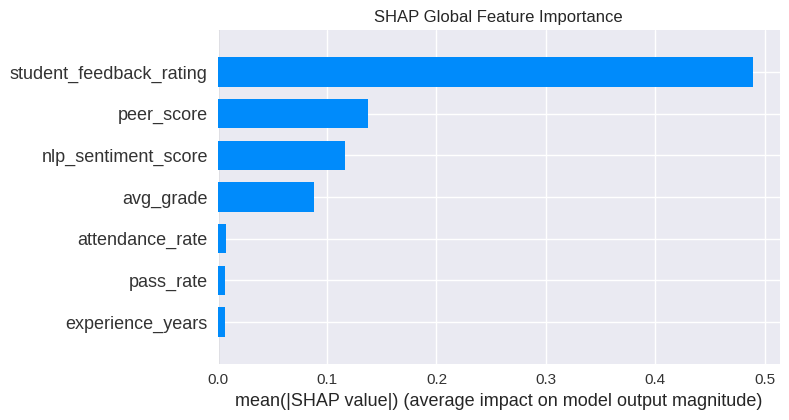

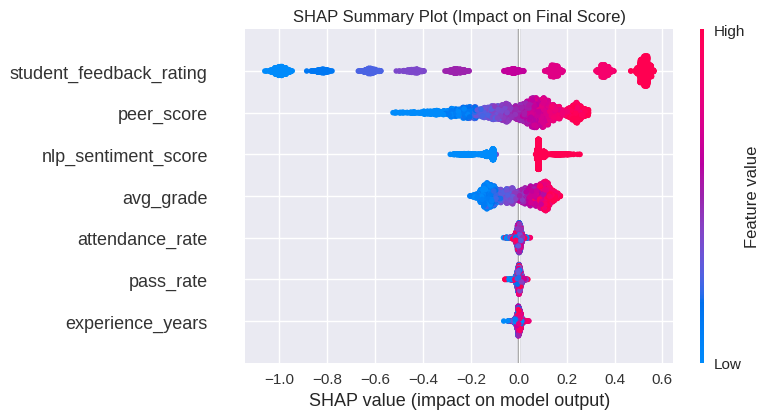

In [7]:
print("... Computing SHAP explanations...")

# SHAP Explainer (TreeExplainer is fast and accurate for RandomForest)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1. Global Summary Plot (feature importance)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig("explanations/shap_global_importance.png", dpi=300)
plt.show()

# 2. SHAP Summary (beeswarm) - shows direction of impact
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (Impact on Final Score)")
plt.tight_layout()
plt.savefig("explanations/shap_summary.png", dpi=300)
plt.show()

# LIME Instance-Level Explanation (Example Faculty)


In [8]:
# === FIXED CELL 8 - LIME Instance-Level Explanation ===

# Make sure the explanations folder exists
import os
os.makedirs("explanations", exist_ok=True)

# Pick one faculty for detailed explanation (change index if you want)
instance_idx = 0
instance = X_test.iloc[instance_idx:instance_idx+1]
true_score = y_test.iloc[instance_idx]

faculty_name = df.iloc[X_test.index[instance_idx]]['faculty_name']
print(f"🔍 Explaining faculty: {faculty_name} | True score: {true_score:.2f}")

# Create LIME Explainer
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    mode="regression",
    discretize_continuous=True
)

# Explain the instance
exp = lime_explainer.explain_instance(
    instance.values[0],
    model.predict,
    num_features=7
)

# === MANUAL DISPLAY (fixes the ImportError) ===
from IPython.display import display, HTML
display(HTML(exp.as_html()))

# Save to HTML file for your report
exp.save_to_file("explanations/lime_explanation.html")
print("✅ LIME explanation saved as explanations/lime_explanation.html")
print("   (You can open this HTML file in any browser)")

🔍 Explaining faculty: Murphy | True score: 3.00


✅ LIME explanation saved as explanations/lime_explanation.html
   (You can open this HTML file in any browser)


# Batch Local Explanations (Top 5 Faculties)

In [9]:
print("Generating local explanations for top 5 faculties...")

for i in range(5):
    idx = X_test.index[i]
    instance = X.iloc[idx:idx+1]
    faculty_name = df.loc[idx, 'faculty_name']
    
    exp = lime_explainer.explain_instance(
        instance.values[0],
        model.predict,
        num_features=5
    )
    
    print(f"\n Faculty: {faculty_name} | Score: {df.loc[idx, 'final_evaluation_score']}")
    exp.as_list()  # prints top contributing features

Generating local explanations for top 5 faculties...

 Faculty: Murphy | Score: 3.0

 Faculty: Douglas  Johansen | Score: 4.27

 Faculty: Daniel  Talham | Score: 3.36

 Faculty: Mark  Damen | Score: 4.56

 Faculty: T.  Moore | Score: 4.25


# Bias Audit via XAI

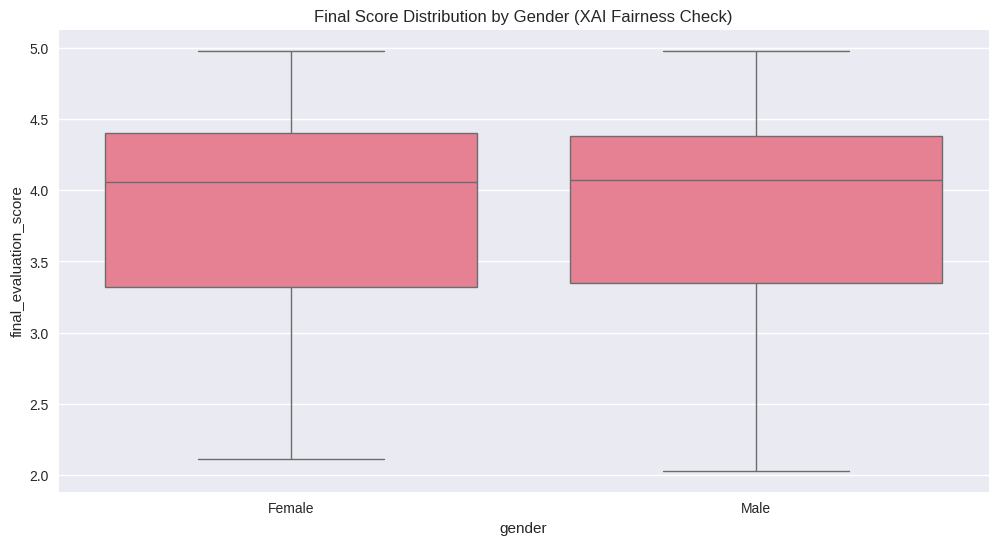

 Statistical Parity Difference (Male - Female): 0.004861262535579947


In [10]:
# Group SHAP values by gender (for fairness report)
df_test = df.loc[X_test.index].copy()
df_test['shap_sum'] = shap_values.sum(axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(x="gender", y="final_evaluation_score", data=df_test)
plt.title("Final Score Distribution by Gender (XAI Fairness Check)")
plt.show()

print(" Statistical Parity Difference (Male - Female):",
      df_test[df_test['gender']=='Male']['final_evaluation_score'].mean() -
      df_test[df_test['gender']=='Female']['final_evaluation_score'].mean())